# EDA Recomendation systems

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Definición del problema

>Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

>En base a los resultados del modelo, los estudiantes deberán desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.


## Carga de datos

In [53]:
df = pd.read_csv('../../data/raw/adult-census-income.csv')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


## Análisis Descriptivo

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


>El conjunto de datos está formado por 15 variables, de las cuales 9 son categóricas y 6 son numéricas. Vemos también que tiene 32561 filas, con ningún elemento nulo como tal  en ninguna de las 15 columnas.

In [55]:
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64

>Vemos cuantos valores únicos vemos en cada uno de los datos.

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


>Vemos las características estadísticas de los datos numéricos.

## Limpieza de datos

### Eliminar duplicados

In [57]:
df.duplicated().sum()

np.int64(24)

>Vemos que hay 24 filas duplicadas entre las 32561, de momento no voy a eliminarlas porque podrian ser datos coincidentes más que duplicados.

### Eliminar información irrelevante

In [58]:
df.drop(['fnlwgt', 'education'], axis=1, inplace=True)

>Elimino las columnas 'fnlwgt' y 'education' por motivos distintos. La primera es porque tanto en la página del ejercicio, como en la página del propio dataset como incluso en el propio dataset me falta información para saber que es. La segunda la elimino porque ya la tengo numerizada en 'education.num' y es redundante tener las dos y la numérica me sirve más.

## Análisis de Variables

### Análisis de Variables Univariante

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education.num'}>],
       [<Axes: title={'center': 'capital.gain'}>,
        <Axes: title={'center': 'capital.loss'}>],
       [<Axes: title={'center': 'hours.per.week'}>, <Axes: >]],
      dtype=object)

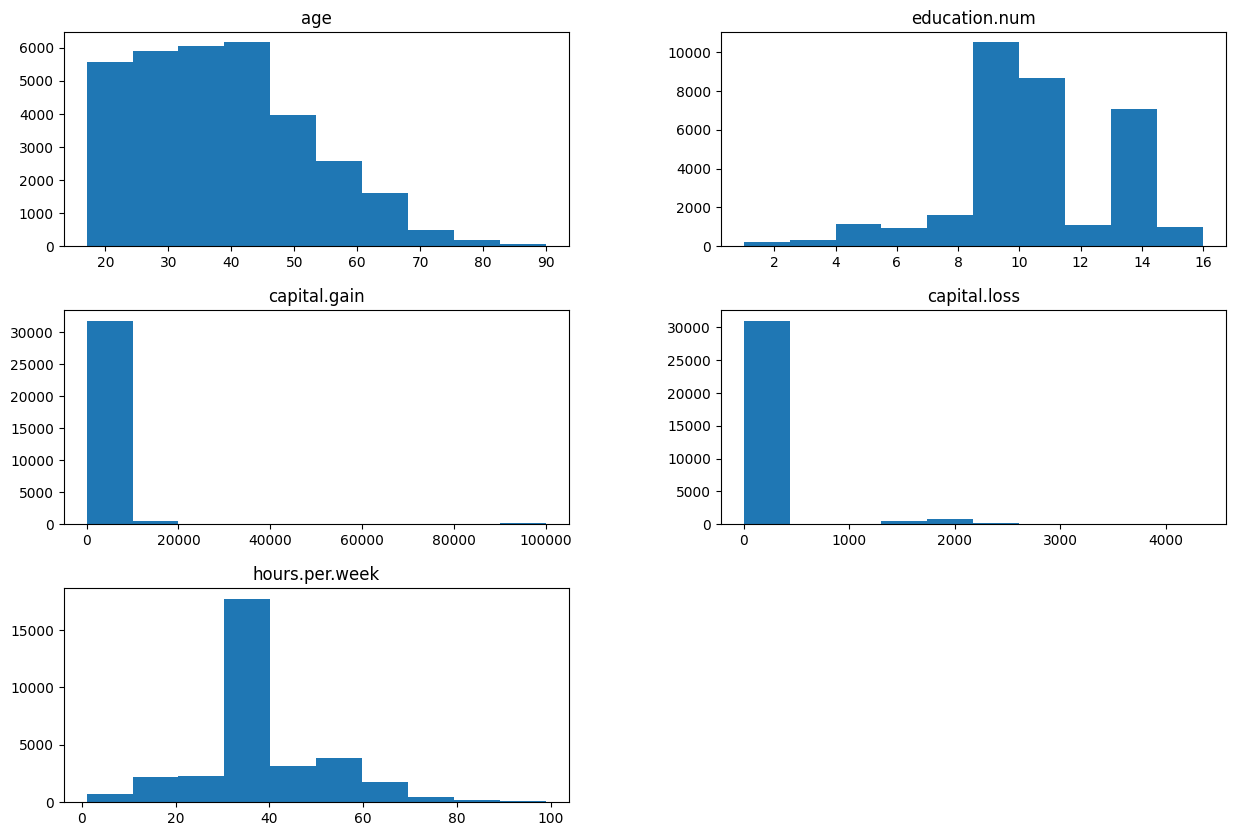

In [59]:
df.hist(figsize=(15, 10), grid=False)

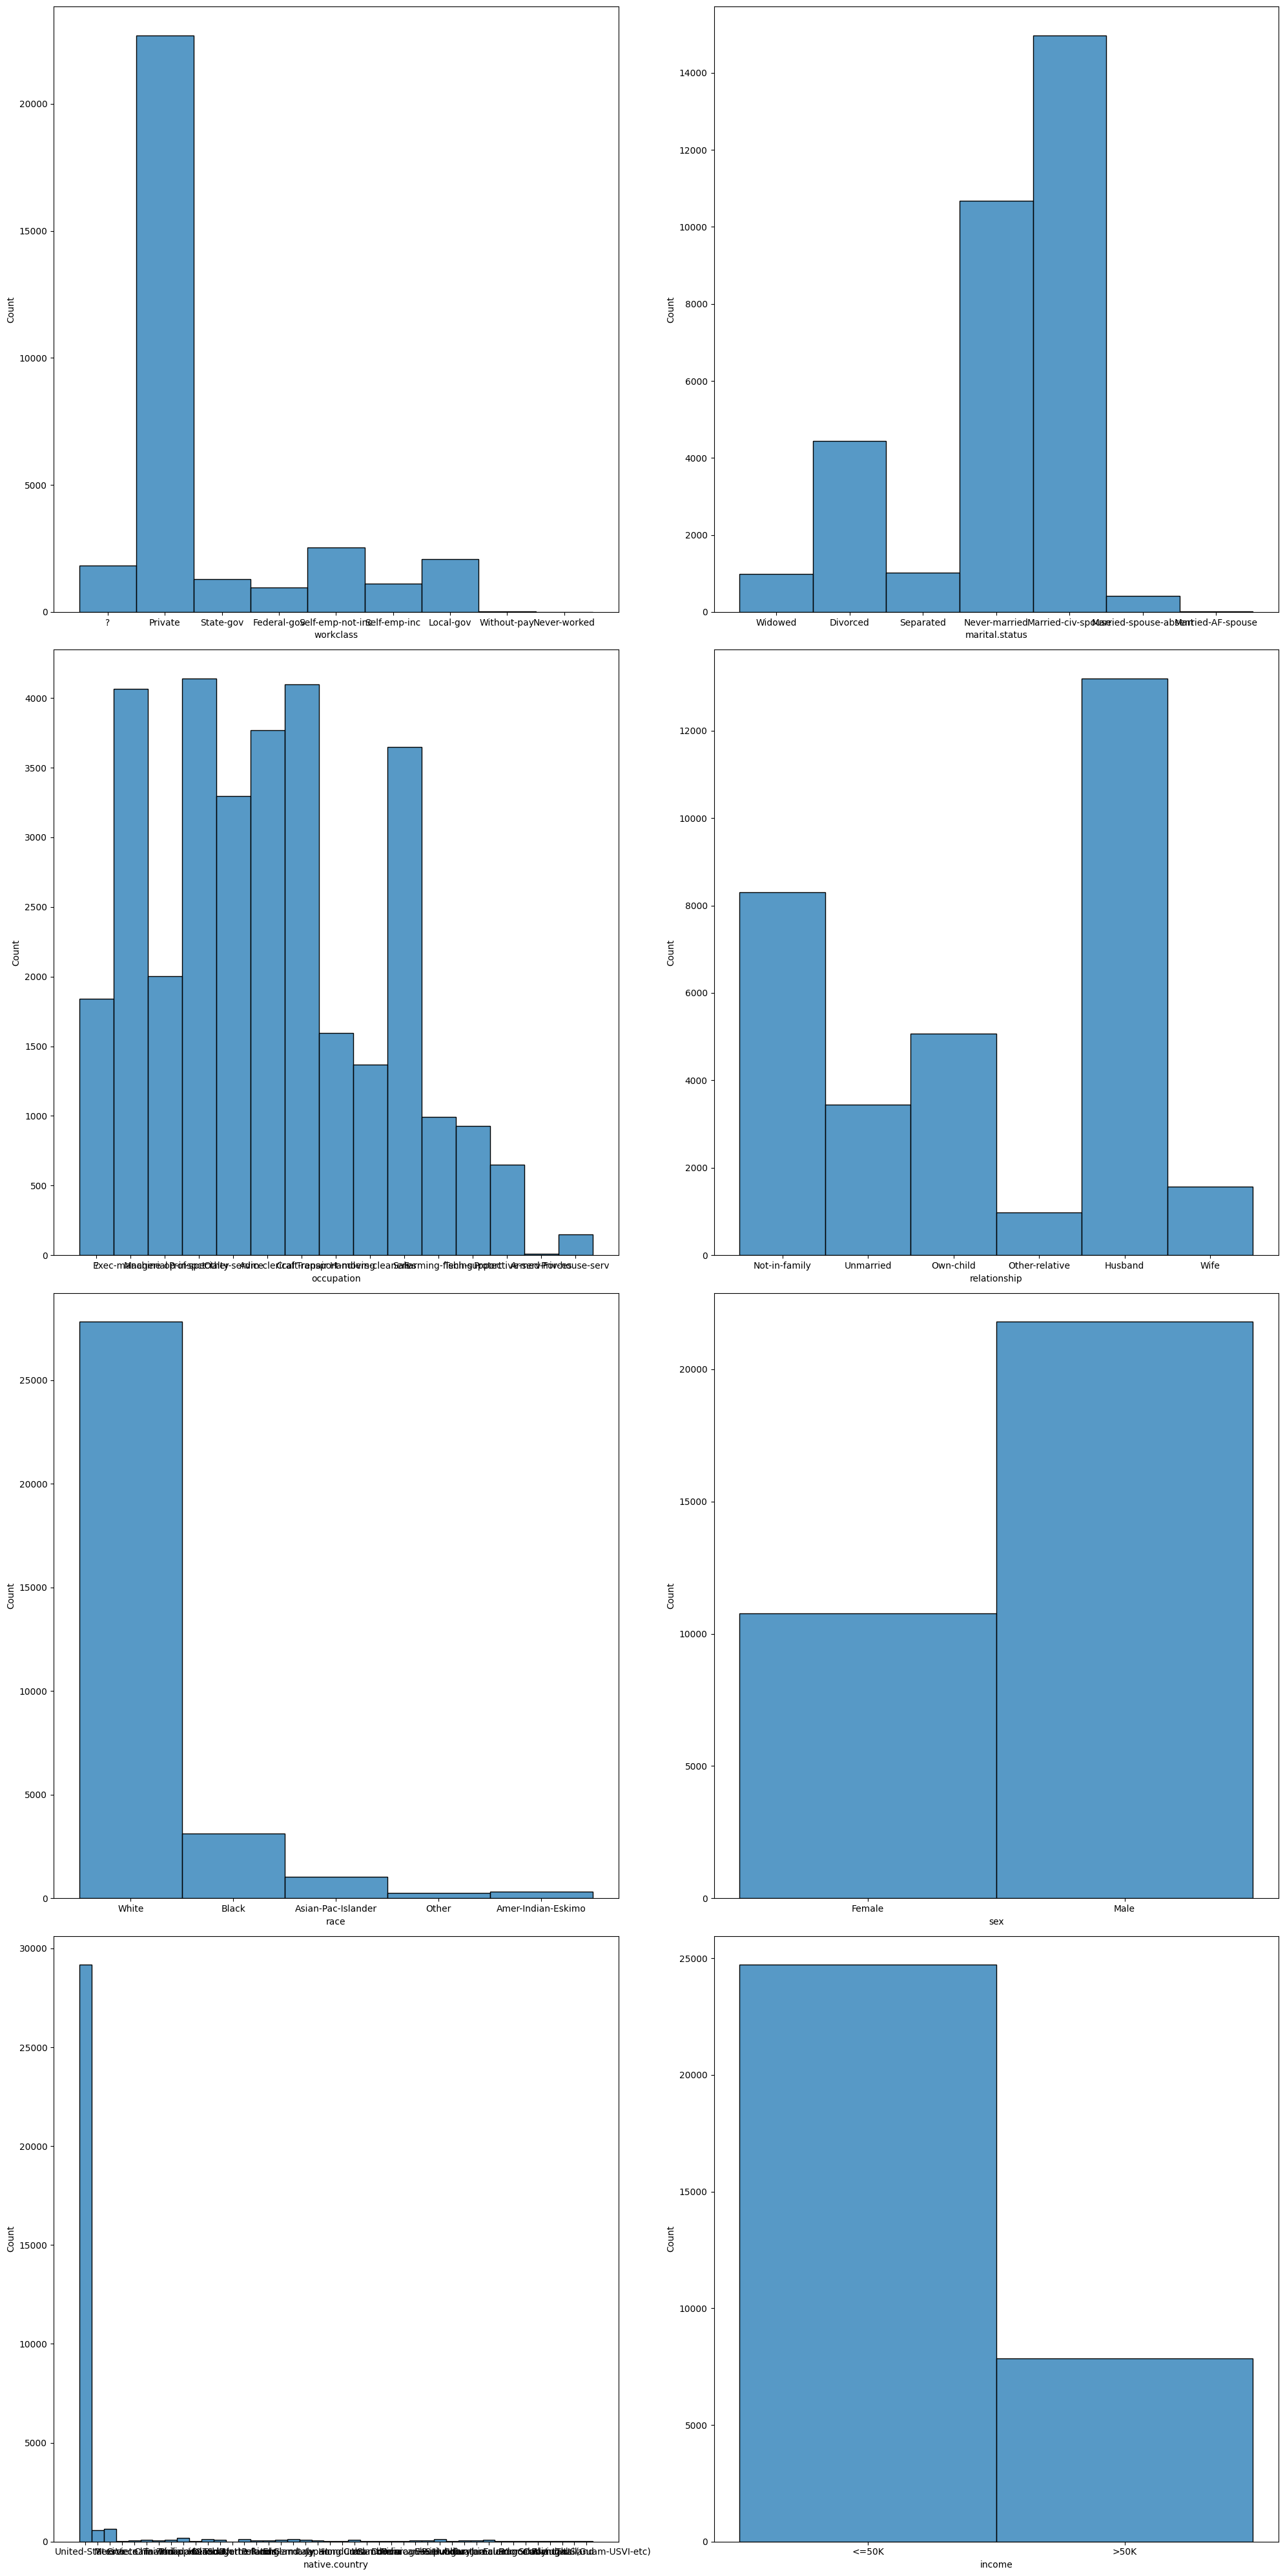

In [60]:
fig, axs = plt.subplots(4, 2, figsize=(20,40))

sns.histplot(ax=axs[0, 0], data=df, x="workclass")
sns.histplot(ax=axs[0, 1], data=df, x="marital.status")
sns.histplot(ax=axs[1, 0], data=df, x="occupation")
sns.histplot(ax=axs[1, 1], data=df, x="relationship")
sns.histplot(ax=axs[2, 0], data=df, x="race")
sns.histplot(ax=axs[2, 1], data=df, x="sex")
sns.histplot(ax=axs[3, 0], data=df, x="native.country")
sns.histplot(ax=axs[3, 1], data=df, x="income")

plt.tight_layout()
plt.show()

### Análisis de Variables Multivariante

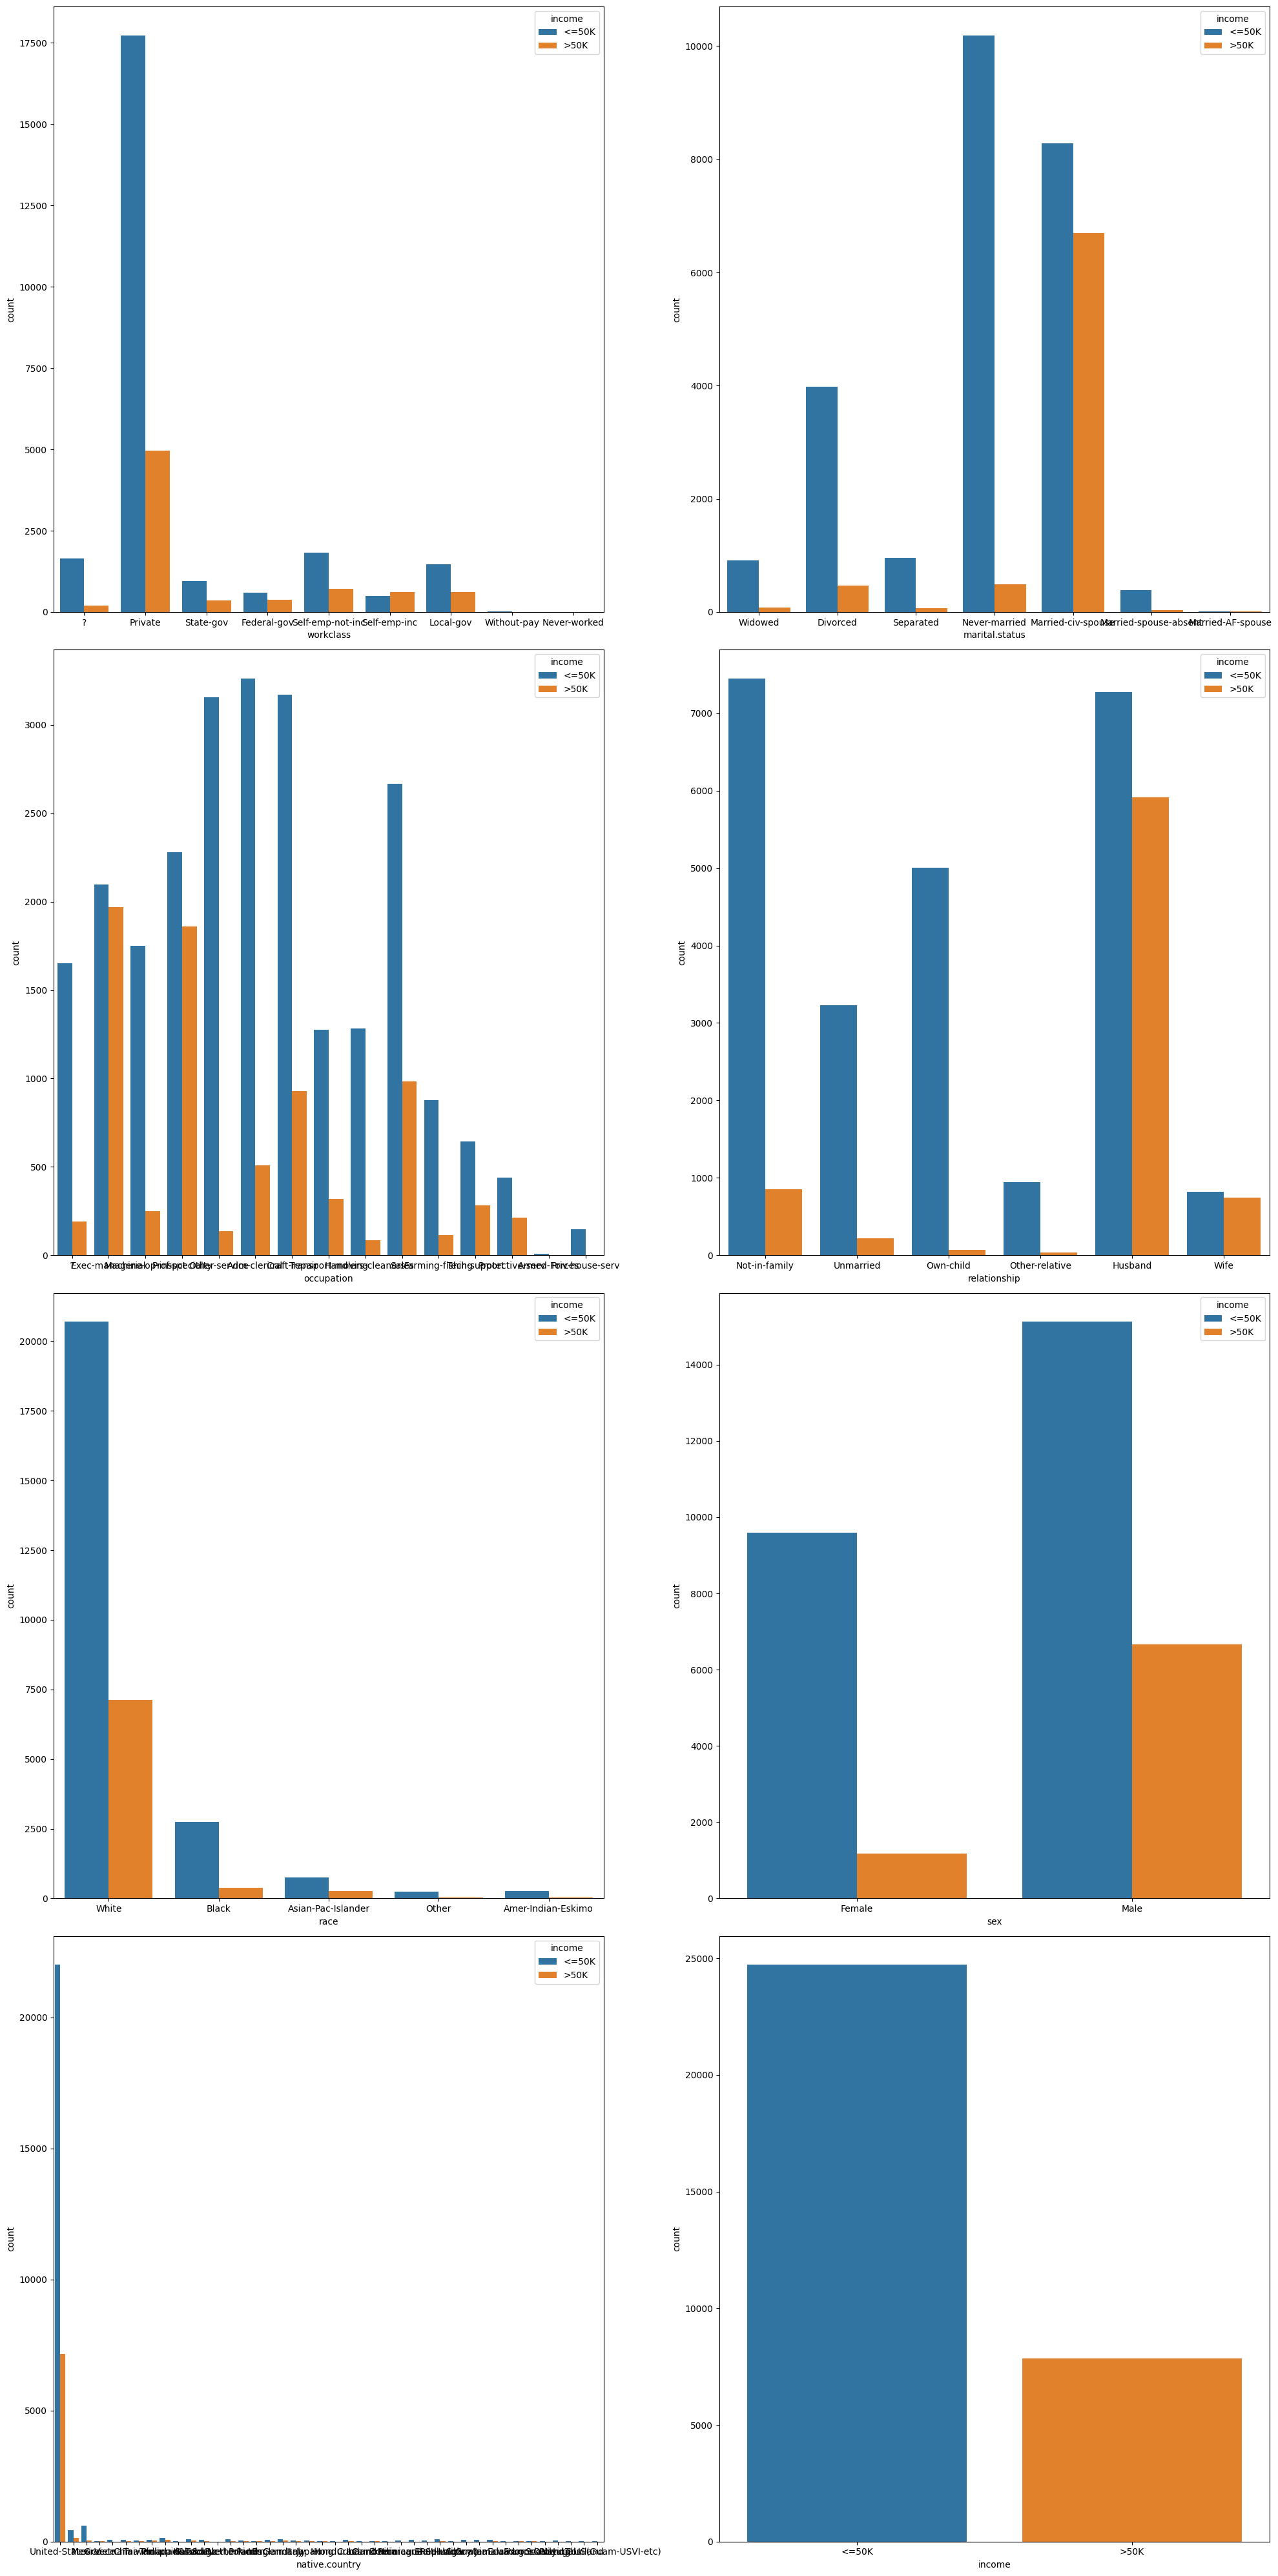

In [61]:
fig, axs = plt.subplots(4, 2, figsize=(20,40))

sns.countplot(ax=axs[0, 0], data=df, x="workclass", hue='income')
sns.countplot(ax=axs[0, 1], data=df, x="marital.status", hue='income')
sns.countplot(ax=axs[1, 0], data=df, x="occupation", hue='income')
sns.countplot(ax=axs[1, 1], data=df, x="relationship", hue='income')
sns.countplot(ax=axs[2, 0], data=df, x="race", hue='income')
sns.countplot(ax=axs[2, 1], data=df, x="sex", hue='income')
sns.countplot(ax=axs[3, 0], data=df, x="native.country", hue='income')
sns.countplot(ax=axs[3, 1], data=df, x="income", hue='income')

plt.tight_layout()
plt.show()

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   education.num   32561 non-null  int64 
 3   marital.status  32561 non-null  object
 4   occupation      32561 non-null  object
 5   relationship    32561 non-null  object
 6   race            32561 non-null  object
 7   sex             32561 non-null  object
 8   capital.gain    32561 non-null  int64 
 9   capital.loss    32561 non-null  int64 
 10  hours.per.week  32561 non-null  int64 
 11  native.country  32561 non-null  object
 12  income          32561 non-null  object
dtypes: int64(5), object(8)
memory usage: 3.2+ MB


In [63]:
df["workclass_n"] = pd.factorize(df["workclass"])[0]
df["marital.status_n"] = pd.factorize(df["marital.status"])[0]
df["occupation_n"] = pd.factorize(df["occupation"])[0]
df["relationship_n"] = pd.factorize(df["relationship"])[0]
df["race_n"] = pd.factorize(df["race"])[0]
df["sex_n"] = pd.factorize(df["sex"])[0]
df["native.country_n"] = pd.factorize(df["native.country"])[0]
df["income_n"] = pd.factorize(df["income"])[0]

In [64]:
df.columns

Index(['age', 'workclass', 'education.num', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'capital.gain', 'capital.loss',
       'hours.per.week', 'native.country', 'income', 'workclass_n',
       'marital.status_n', 'occupation_n', 'relationship_n', 'race_n', 'sex_n',
       'native.country_n', 'income_n'],
      dtype='object')

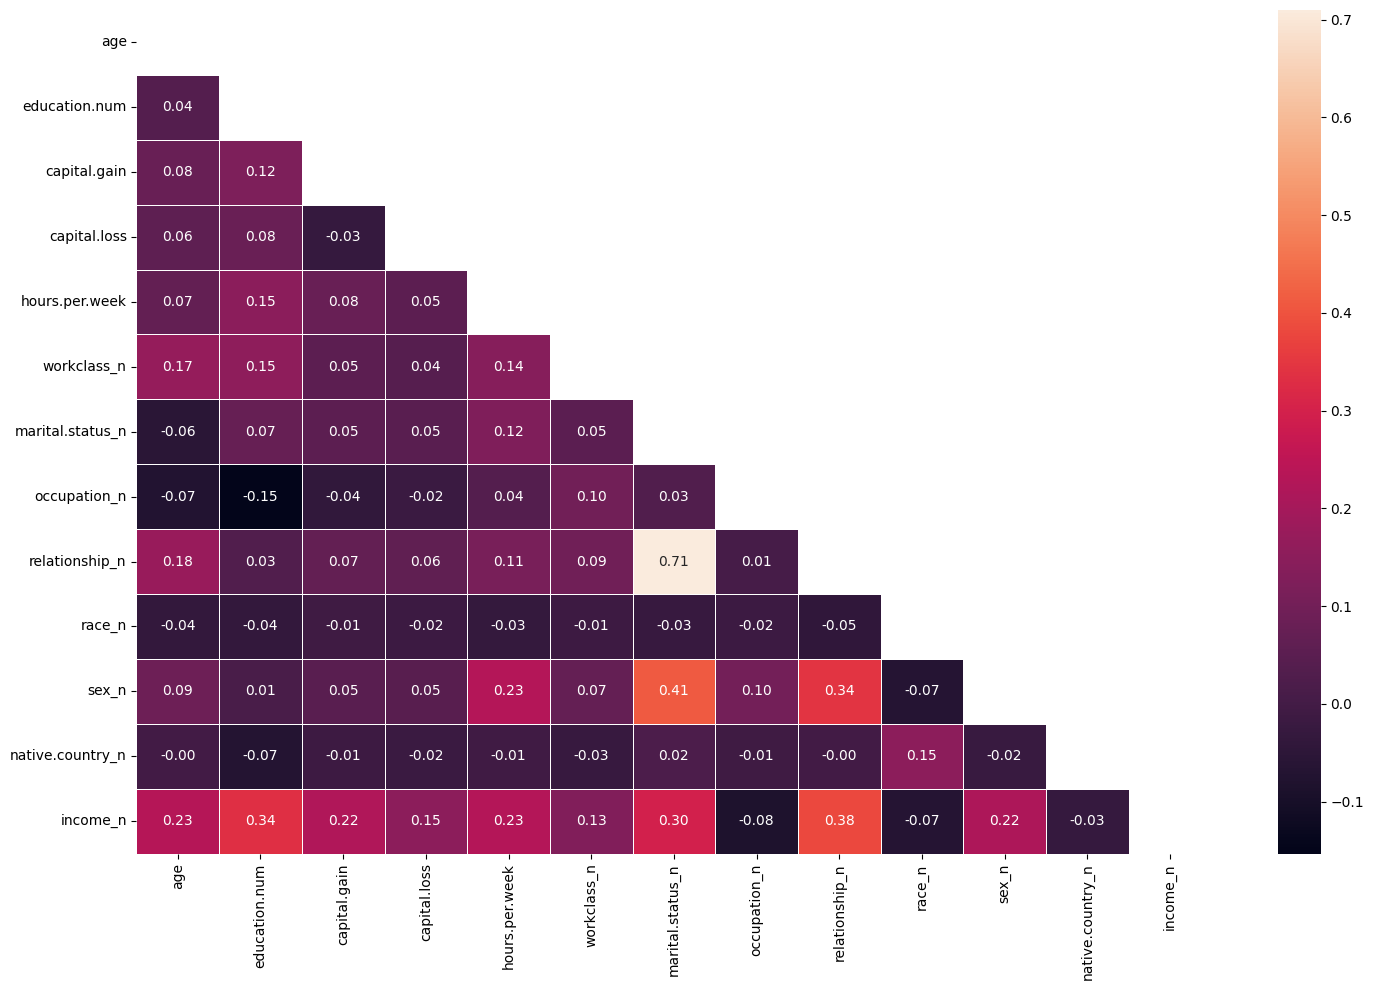

In [65]:
corr = df[['age', 'education.num', 'capital.gain', 'capital.loss',
           'hours.per.week', 'workclass_n', 'marital.status_n', 'occupation_n',
           'relationship_n', 'race_n', 'sex_n', 'native.country_n', 'income_n']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

## Ingeniería de características

### Outliers

### Faltantes

### Inferencia de nuevas caracteristicas

## Split

## Scaling & Encoding

### Encoding

### Scaling

### Guardado de Scalings y Encodings

## Guardado de datos procesados